### Final Project for CMU DSPN Spring 2026 | Luz Stephanie Andrino, PhD Candidate in Systems Neuroscience 



# *Assessing the efficacy of Envelope Following Responses (EFRS) in a model of cochlear neural degeneration (CND) across graded noise exposure* 

# Introduction
> Overexposure to noise can potentially cause a range of
hearing damage, from the loss of cochlear afferent
synapses (cochlear neural degeneration) to permanent
changes in hearing thresholds (permanent threshold shift
or PTS). Cochlear synapse loss and threshold shifts have been
extensively studied in rodent models but PTS effects on
the neural encoding of low-frequency speech cues is still
unclear
.
Here, we use the Mongolian gerbil, a rodent model with
human-like low frequency hearing, to develop a model for
progressive noise damage. Using this model, we ask;
**How does noise exposure affect the neural encoding
of speech-relevant temporal information in the
auditory pathway?**


## Figure 1: Experimental Paradigm
<br>

![Table 1:](timeline.png)


> Noise exposure causes progressive damage to the
auditory system, beginning with cochlear synapse loss
and eventually leading to permanent threshold shifts. We
used a Mongolian gerbil model of PTS and
synapse loss at low frequencies critical for speech
comprehension. The gerbils were exposed to a range of noise exposure intensities - a 100 dB SPL group, 106dB SPL, a 118 dB SPL group - using octave-band noise centered at 1 kHz for 2 hours , and a control group that did not undergo noise exposure.
> To test the
effects of noise damage on auditory
temporal processing using noninvasive, scalp-recorded auditory
evoked potentials with a pre-test and post-test assessment

## Figure 2: Cochlear Neural Degeneration 

<br>

![Table 1:](ribbon_synapses-kujawa-liberman2015.png)
                *(Kujawa & Liberman, 2015)*

> CND is characterized by the loss of synapses between inner hair cells (IHCs) and
auditory nerve fibers (ANFs), often occurring without hair cell loss. In the mammalian cochlea, outside of the
extreme apex, 95% of cochlear nerve fibers are unbranched, each forming a single synaptic connection with one
IHC via a single terminal swelling, which houses a single presynaptic ribbon. A ribbons synapse is critical because its primary function is to facilitate rapid, high fidelity, and sustained signal transmission neccessary for speech perception.
>
> 

## Figure 3: Envelope Following Response (EFR): Neural ensemble responses to sound

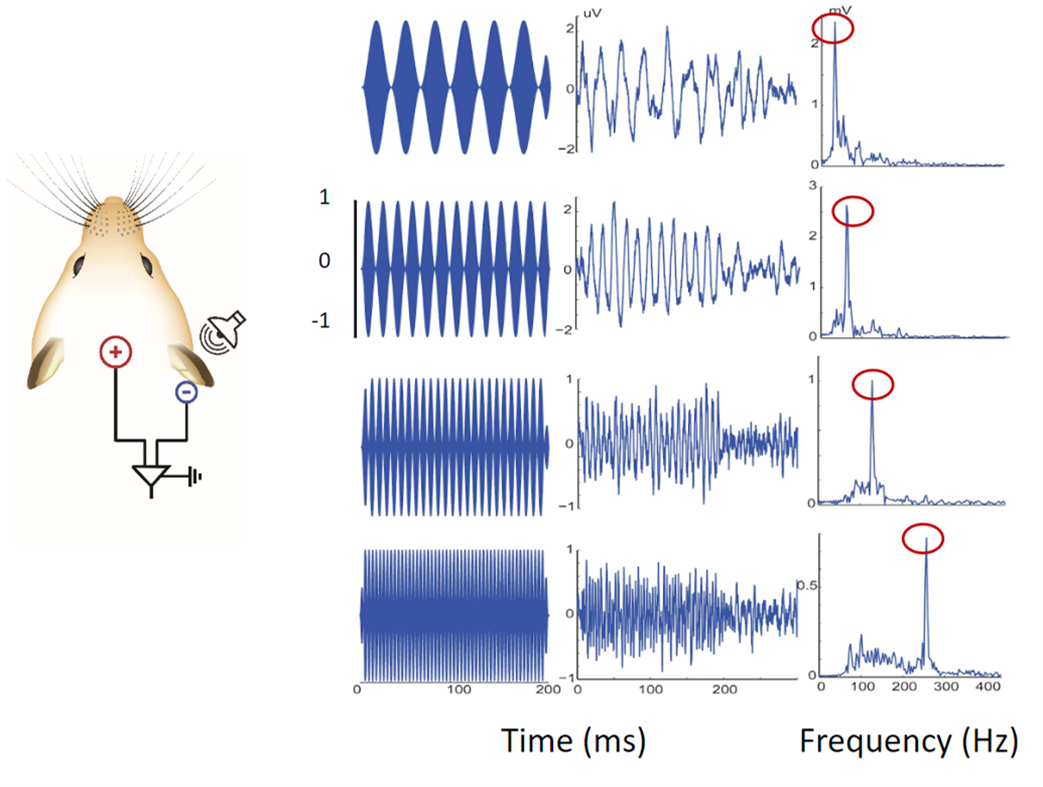

> Envelope following responses (EFRs) provide a non-invasive electrophysiological index of how well the auditory system phase-locks to the temporal envelope of amplitude-modulated sounds. EFRs reflect the synchronized activity of neural populations across the auditory pathway and are particularly sensitive to temporal coding fidelity.

>An EFR is recorded by presenting a carrier frequency and an amplitude-modulated tone— then recording the brain's synchronized neural response to that rhythm using scalp electrodes. The left panel is presented stimulus, the center panel is neural time-domain response, and the right panel shows a clear peak at the modulation frequency in the frequency domain by using a Fast Fourier Transform (FFT). The **peak amplitude of the FFT is what we define as the EFR amplitude** measured in microvolts. By using slow to fast AM rates— we can selectively tap into generators from the cortex to the periphery because of different parts of the neural generators will phase lock to different AM rates. 


 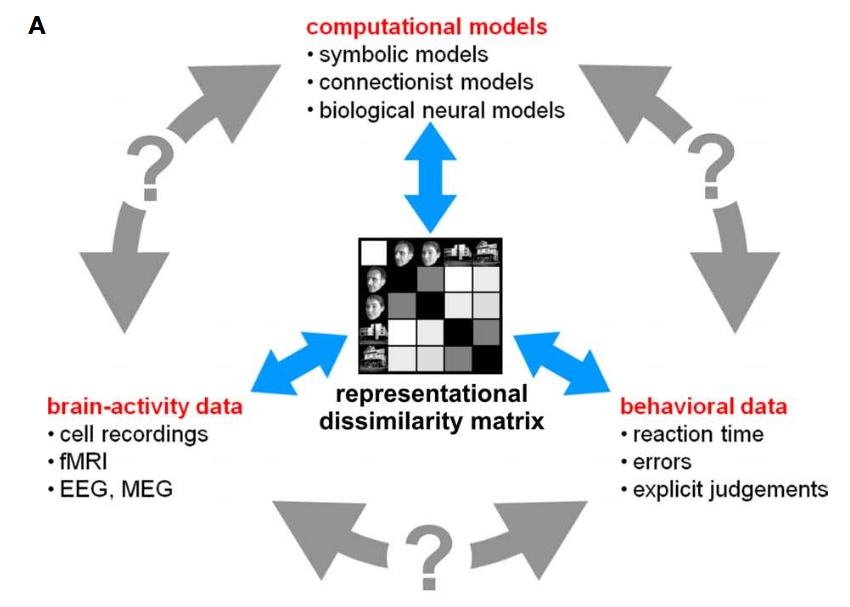
 *Kriegeskorte, Mur, and Bandettini (2008)*
> I will use a novel approach to relate the representations between noise exposure groups using a **Representational Similarity Analysis** and use the representational dissimilarity matrix as a station to relate the different conditions measured by EEG-like responses in a gerbil model and deepen our understanding or even uncover the effects of noise exposure across conditions. 
>
> 

# Hypothesis
### We hypothesized a significant reduction in EFR amplitudes in higher intensity presentations of noise exposure to suggest peripheral degradation occurring in CND. 

### By empolying the RSA we predict a systematic increase in representational dissimilarity structure of EFR amplitude patterns across modulation frequencies in a gerbil model of cochlear neural degeneration shown as the most dissimilar between the highest noise exposure group (118dB) and the control group, reflecting greater degradation of temporal coding at the highest exposure level.


## Data preparation

In [2]:
install.packages("readxl")

Installing package into 'C:/Users/luzsa/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'readxl' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'readxl'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\luzsa\AppData\Local\R\win-library\4.5\00LOCK\readxl\libs\x64\readxl.dll to C:\Users\luzsa\AppData\Local\R\win-library\4.5\readxl\libs\x64\readxl.dll: Permission denied"
Warning message:
"restored 'readxl'"



The downloaded binary packages are in
	C:\Users\luzsa\AppData\Local\Temp\RtmpYXwiai\downloaded_packages


In [3]:
library(tidyverse)
library(ggplot2)
library(reshape2)
library(readxl)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'reshape2' was built under R version 4.5.3"

Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths


Warning message:
"package 'readxl' was built under R version 4.5.3"


In [4]:
#Load in data
efr <- read.csv("noise_exposure_rate.csv")
head(efr)

,noise_group,exposure_timepoint,ger_id,mod_freq,fft_amplitude_nV,X,X.1,X.2,X.3,X.4,X.5,X.6,X.7
,<chr>,<chr>,<chr>,<int>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,118dB,pre,GER34-24,16,11.000,NA,NA,NA,NA,NA,NA,NA,NA
2,118dB,pre,GER34-24,40,33.040,NA,NA,NA,NA,NA,NA,NA,NA
3,118dB,pre,GER34-24,110,19.380,NA,NA,NA,NA,NA,NA,NA,NA
4,118dB,pre,GER34-24,256,9.014,NA,NA,NA,NA,NA,NA,NA,NA
5,118dB,pre,GER34-24,512,17.970,NA,NA,NA,NA,NA,NA,NA,NA
6,118dB,pre,GER34-24,724,3.588,NA,NA,NA,NA,NA,NA,NA,NA


In [5]:
#Data cleaning
efr <- efr %>% 
select(-starts_with("X")) %>%
  drop_na() %>%
    rename(efr_amplitude = fft_amplitude_nV)
head(efr)
dim(efr) #Size of my data

,noise_group,exposure_timepoint,ger_id,mod_freq,efr_amplitude
,<chr>,<chr>,<chr>,<int>,<dbl>
1,118dB,pre,GER34-24,16,11.000
2,118dB,pre,GER34-24,40,33.040
3,118dB,pre,GER34-24,110,19.380
4,118dB,pre,GER34-24,256,9.014
5,118dB,pre,GER34-24,512,17.970
6,118dB,pre,GER34-24,724,3.588


[1] 448   5

In [6]:
efr <- efr  %>%
  mutate(noise_group = factor(noise_group, levels = c("control", "100dB", "106dB", "118dB")))  #Classify as categorical groups         

## Data Variables
**noise_group**: Label for the noise exposure group the gerbil was in for control, 100dB, 106dB, and 118db.

**exposure_timepoint**: Whether the responses were collected before noise-exposure (pre) or after noise exposure (post). 

**ger ID** (GERXX-XX) : The animal ID is denoted by ger for gerbil model, then the ID and year it was born. 

**mod_freq**: The presented amplitude modulation frequency in Hz from slow to fast AM rates to target cortical to peripheral generators (16-1448Hz).

**efr_amplitude**: The key neural response we are tracking, EFR amplitudes defined as peak amplitudes of the FFT at the presented amplitude modulation frequency.

#### Separate dataframes for pre and post timepoints
>Primarily analyze post-data, the dose-dependent group to compare those group differences. Pre-exposure should have minimal group differences and can be used an overall control.


In [7]:
df_post <- efr %>% filter(exposure_timepoint == "post")
df_pre  <- efr %>% filter(exposure_timepoint == "pre")
 
cat("Post-exposure:", nrow(df_post), "\n") 
cat("Pre-exposure: ", nrow(df_pre),  "\n")

Post-exposure: 224 
Pre-exposure:  224 


## Pipeline outline

1. Build empirical RDM using 1 &rarr; Pearson correlation as the distance metric
2. Spearman correlation between empirical RDM and each model RDM &rarr; technique #1
3. Permutation testing to assess statistical significance of that correlation &rarr; technique #2
4. Bootstrapping for confidence intervals on the Spearman correlation &rarr; technique #3

## 1. Empirical RDM: 
## How dissimilar are the EFR amplitude patterns between noise exposure groups after noise exposure?
*How does noise expsoure alter the represenational geometry of temporal coding measured by RDM?*


>Activity pattern for each group = vector of 8 mean efr amplitudes across the 8 modulation frequencies. 

>Dissimilarity between two groups = 1 - Pearson correlation

>4x4 RDM (one cell per pair of noise groups).
   

In [8]:
group_order <- c("control", "100dB", "106dB", "118dB")

#Create a mean EFR amplitude matrix
efr_mat <- function(data) {
  data %>%
    group_by(noise_group, mod_freq) %>%
    summarise(mean_amp = mean(efr_amplitude, na.rm = TRUE), .groups = "drop") %>% #Compute mean amplitudes across groups
    pivot_wider(names_from = mod_freq, values_from = mean_amp) %>%
    arrange(factor(noise_group, levels = group_order)) %>% #Arrange by noise exposure groups
    column_to_rownames("noise_group")
}

pattern_post <- efr_mat(df_post)
pattern_pre  <- efr_mat(df_pre)

In [9]:
#Raw mean EFR amplitudes for all groups for each modulation frequency in Pre-test
print(pattern_pre) 

              16       40      110       256       512      724     1024
control 17.56067 17.43917 13.29917  9.242333 10.401667 4.089667 4.063567
100dB   17.18329 17.75014 11.94243  7.691571  8.438429 3.777857 2.787714
106dB   22.18540 15.23660 14.68260 13.217600  9.353600 2.725600 2.497200
118dB   18.92790 22.61570 12.80910  6.030400  7.328080 5.078100 3.134550
            1448
control 1.286800
100dB   1.177057
106dB   1.444200
118dB   1.338324


In [10]:
#Raw mean EFR amplitudes for all groups for each modulation frequency in Post-test
print(pattern_post)

              16       40       110       256     512       724     1024
control 11.87550 16.74333 10.814667  9.832167  8.1130  3.274817 2.712667
100dB   19.00143 18.98429  9.729857  5.159000  6.0130  2.893714 2.468443
106dB   15.76460 18.80000 14.194800 13.427200  9.0540  4.579940 3.401400
118dB   29.32130 23.29590 13.217900 12.613000 20.9623 16.109500 5.743410
             1448
control 0.9607833
100dB   1.2363286
106dB   1.6078000
118dB   1.4298150


In [11]:
matrix <- base::matrix

In [12]:
rm(matrix)

## Create the dissimilarity matrix (rdm) using 1-pearson correlation 
*Pearson correlation is used here to build the dissimilarity matrix between patterns defined as the data EFR amplitudes*

In [13]:
#Create a function to create the RDM called pattern_mat
rdm <- function(pattern_mat) {
  n <- nrow(pattern_mat)
  rdm <- base::matrix(0, nrow = n, ncol = n,
                      dimnames = list(rownames(pattern_mat),
                                      rownames(pattern_mat)))
  for (i in 1:n) {
    for (j in 1:n) {
      if (i != j) {
        rdm[i, j] <- 1 - cor(
          as.numeric(pattern_mat[i, ]),
          as.numeric(pattern_mat[j, ]),
          method = "pearson"
        )
      }
    }
  }
  return(rdm)
}

In [14]:
rdm #RDM function

function (pattern_mat) 
{
    n <- nrow(pattern_mat)
    rdm <- base::matrix(0, nrow = n, ncol = n, dimnames = list(rownames(pattern_mat), 
        rownames(pattern_mat)))
    for (i in 1:n) {
        for (j in 1:n) {
            if (i != j) {
                rdm[i, j] <- 1 - cor(as.numeric(pattern_mat[i, 
                  ]), as.numeric(pattern_mat[j, ]), method = "pearson")
            }
        }
    }
    return(rdm)
}

In [15]:
rdm_post <- rdm(pattern_post)
rdm_pre  <- rdm(pattern_pre)

In [16]:
#Pre-Exposure dissimlarity matrix
print(rdm_pre)

            control       100dB      106dB      118dB
control 0.000000000 0.008084665 0.05574148 0.05205886
100dB   0.008084665 0.000000000 0.07307490 0.02191775
106dB   0.055741478 0.073074904 0.00000000 0.15869803
118dB   0.052058863 0.021917749 0.15869803 0.00000000


In [17]:
#Post-Exposure dissimlarity matrix
print(rdm_post)

           control     100dB      106dB     118dB
control 0.00000000 0.1134083 0.01303797 0.2515218
100dB   0.11340834 0.0000000 0.12233461 0.1788508
106dB   0.01303797 0.1223346 0.00000000 0.2592238
118dB   0.25152182 0.1788508 0.25922383 0.0000000


# Visualize Pre- and Post-Exposure Mean EFR amplitudes

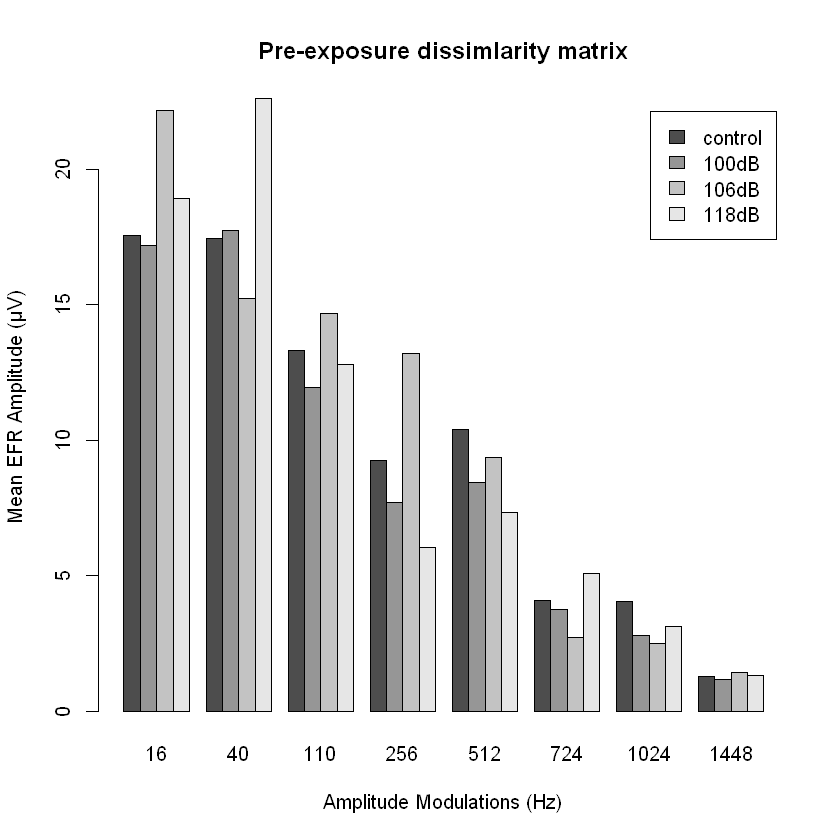

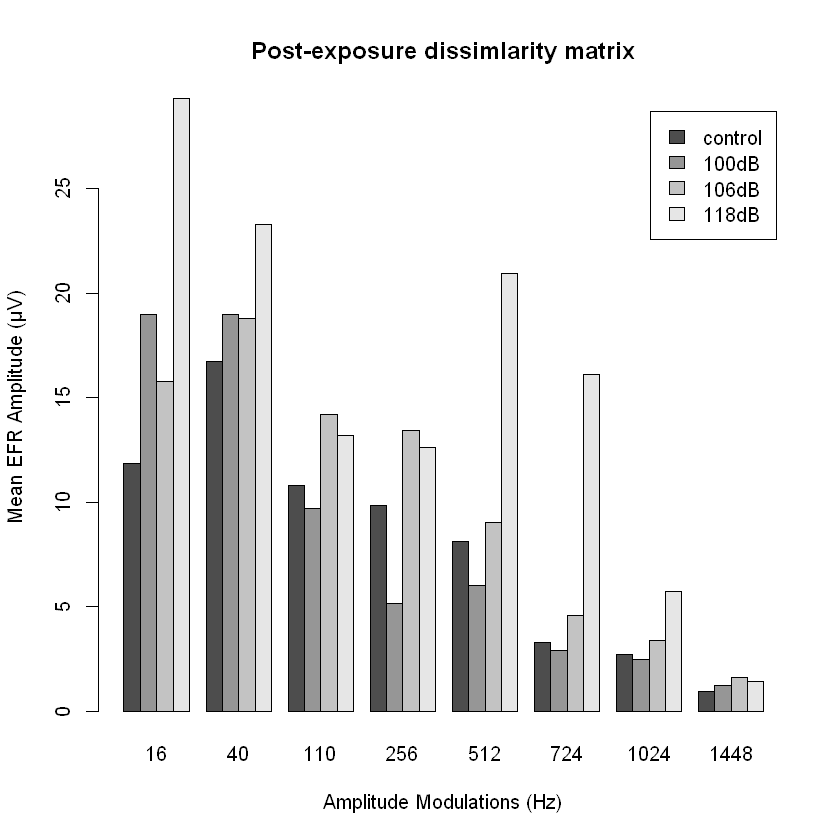

In [18]:
barplot(as.matrix(pattern_pre), beside = TRUE, legend.text = rownames(pattern_pre), xlab = 'Amplitude Modulations (Hz)', ylab = "Mean EFR Amplitude (µV)", main = "Pre-exposure dissimlarity matrix")
barplot(as.matrix(pattern_post), beside = TRUE, legend.text = rownames(pattern_post), xlab = 'Amplitude Modulations (Hz)', ylab = "Mean EFR Amplitude (µV)", main = "Post-exposure dissimlarity matrix")

# add x and y labels

# Visualize Pre- and Post-Exposure RDM's

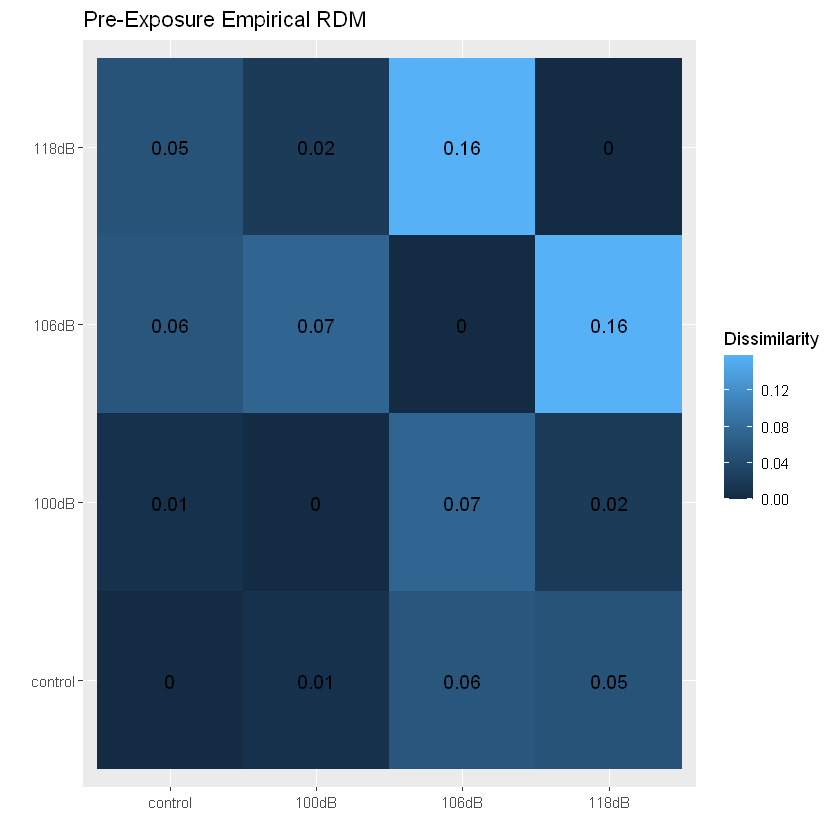

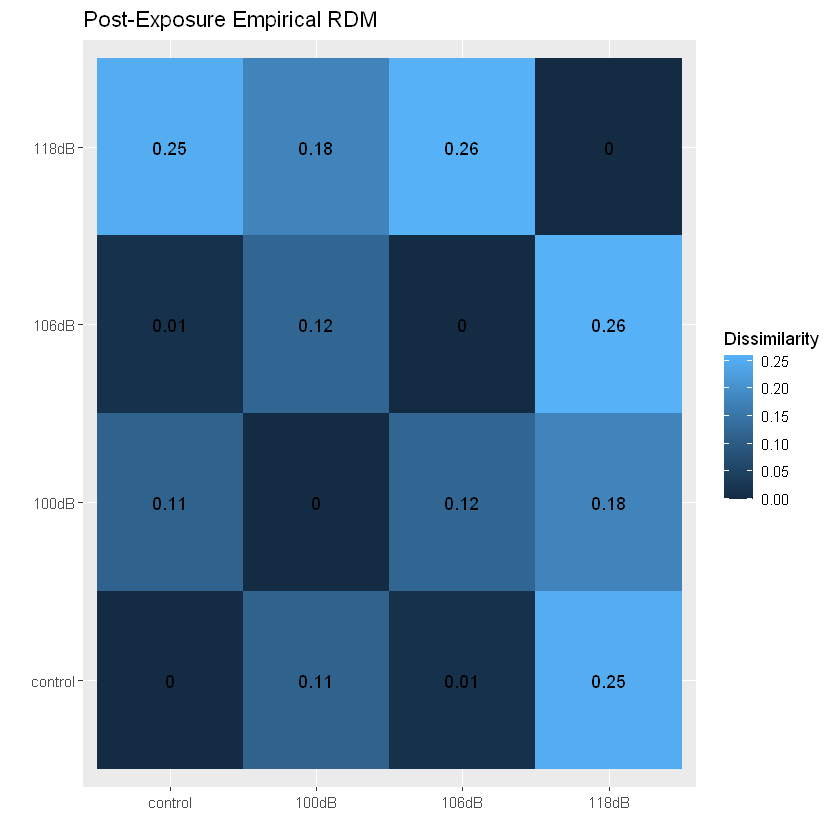

In [19]:
melt(rdm_pre) %>%
  ggplot(aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = round(value, 2)), size = 4) +
  labs(title = "Pre-Exposure Empirical RDM ", x = "", y = "", fill = "Dissimilarity")


melt(rdm_post) %>%
  ggplot(aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = round(value, 2))) +
  labs(title = "Post-Exposure Empirical RDM", x = "", y = "", fill = "Dissimilarity")

## 1. Empirical RDM conclusion 
The post-exposure empirical RDM assessed the dissimilarity relationships among noise-exposed groups, where 0 indicates perfectly similar EFR patterns. As expected, the diagonal reports 0s, confirming each group is identical to itself. Dissimilarity values above 0.20 indicate higher representational distance between groups. The RDM revealed a dissimilarity of 0.25 between the two most extreme conditions the 118dB group and the control group which was an expected outcome given the large difference in noise exposure. Control-100dB and 100dB-106dB showed dissimilarities of 0.11 and 0.12 respectively, suggesting more gradual representational differences between adjacent exposure levels. However, the highest dissimilarity of all pairs was between 106dB and 118dB at 0.26, which was unexpected. Rather than 100dB-118dB being the most dissimilar non-control pair, it was 106dB-118dB, suggesting that the 106dB exposure level produced a more distinct effect in the EFR representational structure than expected.

# Building RDM Models
-  Group membership model: Predicts that same noise group = more similar EFR patterns. We expect to see that groups will cluster by the noise exposure level if the noise exposure is inducing temporal coding deficits. 
 - #### Dose-response gradient — the more different the groups exposure levels are, the more dissimilar their EFR patterns will be.
- increased noise exposure → decreased EFR amplitude → degraded temporal coding

In [21]:
n_groups <- length(group_order)
n_groups
group_order

[1] 4

[1] "control" "100dB"   "106dB"   "118dB"

In [22]:
doses <- c(0, 100, 106, 118) #Rather than a same or not same model we are treating this as a graded dose of exposure

In [23]:
group_model_rdm <- base::matrix(0, nrow = 4, ncol = 4,
                                dimnames = list(group_order, group_order))
for (i in 1:4) {
  for (j in 1:4) {
    group_model_rdm[i, j] <- abs(doses[i] - doses[j])
  }
}

print(group_model_rdm)

        control 100dB 106dB 118dB
control       0   100   106   118
100dB       100     0     6    18
106dB       106     6     0    12
118dB       118    18    12     0


#### Here, I have created a model RDM that encodes my **theoretical prediction**, where each noise exposure group will show a distinct representational structure, where animals from different groups are more dissimilar than animals from the same group.

### 2a. Spearman correlation: To compare the empirical RDM and model RDM

> *Spearman correlation is used here to compare the correlations between the empricial RDM (meaning my datas RMDs) and the Model RDMs. It compares the acvitity patterns associated with each pair of conditions to begin to compute the RDM from 0 to 1 to show a weak to strong relationship*
> > To calculate the spearman correlation I use the lower triangle of empirical RDM and each model RDM. 

In [24]:
empirical_vector <-rdm_post[lower.tri(rdm_post)]
model_vector <- group_model_rdm[lower.tri(group_model_rdm)]

In [25]:
print(empirical_vector)
print(model_vector)

[1] 0.11340834 0.01303797 0.25152182 0.12233461 0.17885084 0.25922383
[1] 100 106 118   6  18  12


In [26]:
spearmanCorr_post <-  cor(empirical_vector, model_vector, method = "spearman")
print(spearmanCorr_post)

[1] -0.2


In [27]:
empirical_vector_pre <-rdm_pre[lower.tri(rdm_pre)]
model_vector_pre <- group_model_rdm[lower.tri(group_model_rdm)]
spearmanCorr_pre <-  cor(empirical_vector_pre, model_vector_pre, method = "spearman")


print(empirical_vector_pre)
print(model_vector_pre)
print(spearmanCorr_pre)

[1] 0.008084665 0.055741478 0.052058863 0.073074904 0.021917749 0.158698026
[1] 100 106 118   6  18  12
[1] -0.4857143


In [28]:
cat("Spearman r (post):", round(spearmanCorr_post, 3), "\n")
cat("Spearman r (pre):", round(spearmanCorr_pre, 3), "\n")

Spearman r (post): -0.2 
Spearman r (pre): -0.486 


# 2a. Spearman Correlation conclusion
> The spearman correlation is measuring the how well the model RDM can predict the emprirical RDM, it showed a weak and negative correlation for both post-exposure (r = -0.20) and pre-exposure (r = -0.49). This suggests that the difference in noise exposure conditions did *not* predict the representational dissimilarity structure observed in the EFR data as expected.
>
>Additionally, the stronger negative correlation pre-exposure than post-exposure was unexpected, as groups should not differ by noise dose before the exposure has occurred. These results suggest an alternative forma of analysis other than a simple linear dose-response model may not fully capture the representational geometry of EFR patterns across noise exposure groups, consistent with the non-monotonic pattern observed in the empirical RDM especially in the 106dB group that is behaving unexpectedly.
>
> 

# 2b. Compare the empirical RDM and new model RDM using euclidean distance
> To address the weak and negative correlations computed using the group comparison model, I am now epmploying the euclidean distance metric between group amplitudes for building the model RDM and computing the Spearman correlation on original empirical RDM vector and the model RDM now created using the euclidean to better capture the representational geometry.

In [29]:
group_model_rdm_euclid <- base::matrix(0, nrow = 4, ncol = 4,
                                       dimnames = list(group_order, group_order))

for (i in 1:4) {
  for (j in 1:4) {
    group_model_rdm_euclid[i, j] <- dist(rbind(
      as.numeric(pattern_post[i, ]),
      as.numeric(pattern_post[j, ])
    ))
  }
}

print (group_model_rdm_euclid)

          control     100dB     106dB    118dB
control  0.000000  9.138207  6.869232 26.45826
100dB    9.138207  0.000000 10.578719 24.52998
106dB    6.869232 10.578719  0.000000 22.04245
118dB   26.458262 24.529976 22.042449  0.00000


In [30]:
model_vector_euclid <- group_model_rdm_euclid[lower.tri(group_model_rdm_euclid)]

spearmanCorr_post_euclid <- cor(empirical_vector, model_vector_euclid, method = "spearman")

cat("Spearman r (post-exposure using Euclidean model):", round(spearmanCorr_post_euclid, 2), "\n")

Spearman r (post-exposure using Euclidean model): 0.83 


# 2b. Spearman Correlation conclusion using euclidean group model 
> Now using the model RDM computed by euclidean distance to measure how well it predicts the empirical RDM, the spearman correlation reported a much stronger relationship (r = 0.83) thus suggesting the representational structure is better captured by the shape of the EFR profiles than by noise exposure dose alone.

# 3. Permutation testing: 
## Null Hypothesis Significance Testing (NHST), a binary decision framework.  

In [31]:
#Setup
set.seed(42)
n_perms   <- 10000
n         <- nrow(rdm_post)
null_dist <- numeric(n_perms)

This loop runs 10,000 times each time shuffling the rows and columns of rdm_post and recomputing the Spearman correlation. 

In [32]:
for (p in 1:n_perms) {
  idx          <- sample(n) 
  perm_rdm     <- rdm_post[idx, idx]
  null_dist[p] <- cor(perm_rdm[lower.tri(perm_rdm)], model_vector, method = "spearman")
}

In [33]:
p_val <- mean(null_dist >= spearmanCorr_post)
print(p_val)

[1] 0.541


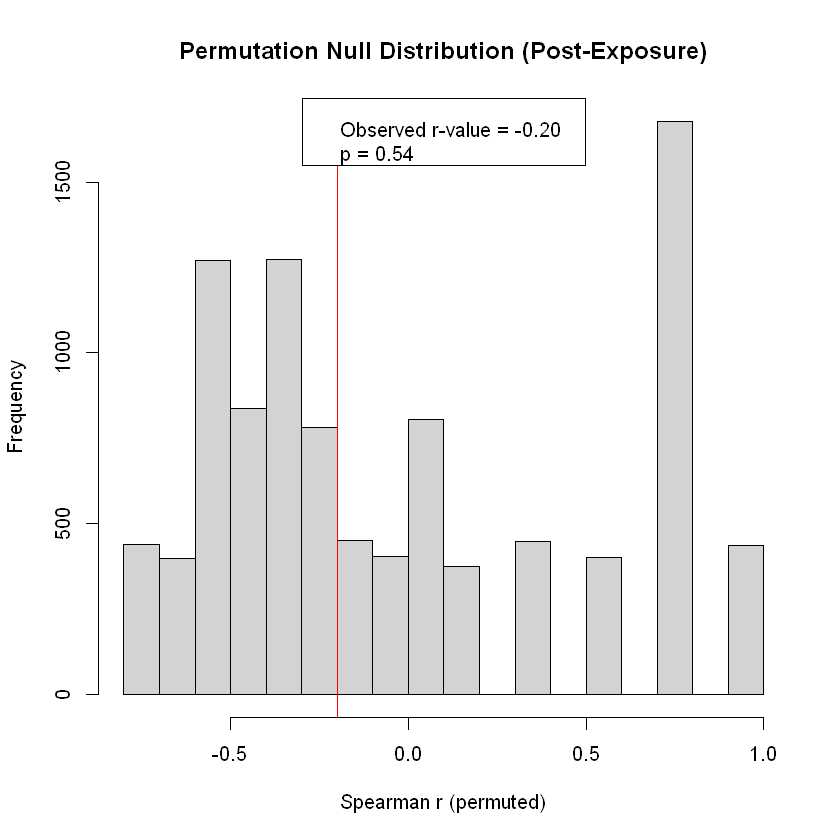

In [34]:
hist(null_dist, breaks = 20, main = "Permutation Null Distribution (Post-Exposure)", xlab = "Spearman r (permuted)")
abline(v = spearmanCorr_post, col = "red")
legend("top",
       legend = sprintf("Observed r-value = %.2f\np = %.2f", spearmanCorr_post, p_val))

In [35]:
cat("Spearman r-value (post):", round(spearmanCorr_post, 3), "\n")
cat("Permutation p-value (post):", round(p_val, 3), "\n")

Spearman r-value (post): -0.2 
Permutation p-value (post): 0.541 


### Permutation testing now using Model RDM-Euclidean 

Spearman r (Euclidean model): 0.829 
Permutation p-value (Euclidean model): 0.1638 


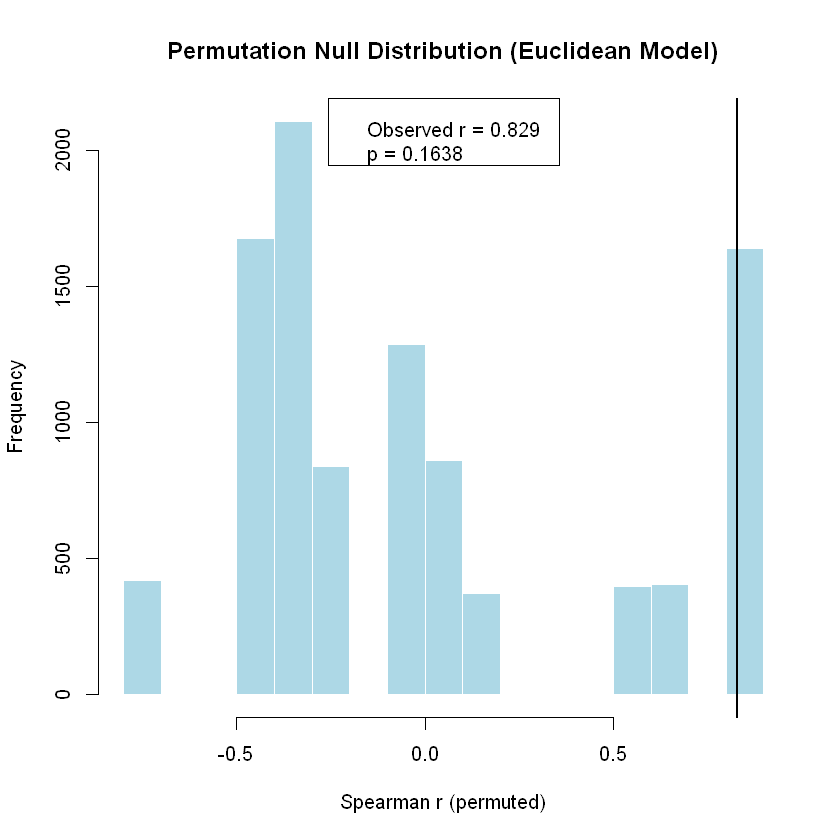

In [36]:
set.seed(42)
n_perms        <- 10000
n              <- nrow(rdm_post)
null_dist_euclid <- numeric(n_perms)

for (p in 1:n_perms) {
  idx                <- sample(n)
  perm_rdm           <- rdm_post[idx, idx]
  null_dist_euclid[p] <- cor(perm_rdm[lower.tri(perm_rdm)], 
                              model_vector_euclid, method = "spearman")
}

p_val_euclid <- mean(null_dist_euclid >= spearmanCorr_post_euclid)
cat("Spearman r (Euclidean model):", round(spearmanCorr_post_euclid, 3), "\n")
cat("Permutation p-value (Euclidean model):", round(p_val_euclid, 4), "\n")

# Plot histogram
hist(null_dist_euclid, breaks = 20, col = "lightblue", border = "white",
     main = "Permutation Null Distribution (Euclidean Model)",
     xlab = "Spearman r (permuted)")
abline(v = spearmanCorr_post_euclid, lwd = 2)
legend("top",
       legend = sprintf("Observed r = %.3f\np = %.4f", 
                        spearmanCorr_post_euclid, p_val_euclid))

# 3. Permutation testing-NHST conclusion  
> The permutation test for the noise dose-based model revealed a weak negative Spearman (r=0.2) with an insignificant (p-val = 0.541), suggesting that the absolute difference in noise exposure level did not significantly predict the representational dissimilarity structure observed in the post-exposure EFR data.
>
> While the Euclidean distance model showed a stronger Spearman (r = 0.83), however the permutation p-value (p-val = 0.164) was also insignificant. 

# 4. Bootstrapping: resample the conditions

In [37]:
#Setup
set.seed(42)
n_boots   <- 10000
boot_dist <- numeric(n_boots)

In [38]:
for (b in 1:n_boots) {
  idx            <- sample(n, replace = TRUE)
  boot_emp       <- rdm_post[idx, idx]
  boot_model     <- group_model_rdm[idx, idx]
  ev             <- boot_emp[lower.tri(boot_emp)]
  mv             <- boot_model[lower.tri(boot_model)]
  boot_dist[b]   <- if (sd(ev) == 0 | sd(mv) == 0) NA
                    else cor(ev, mv, method = "spearman")
}

In [39]:
#Compute confidence intervals
ci <- quantile(boot_dist, c(0.025, 0.975), na.rm = TRUE)

cat("95% Bootstrap CI: [", round(ci[1], 3), ",", round(ci[2], 3), "]\n")

95% Bootstrap CI: [ -0.2 , 1 ]


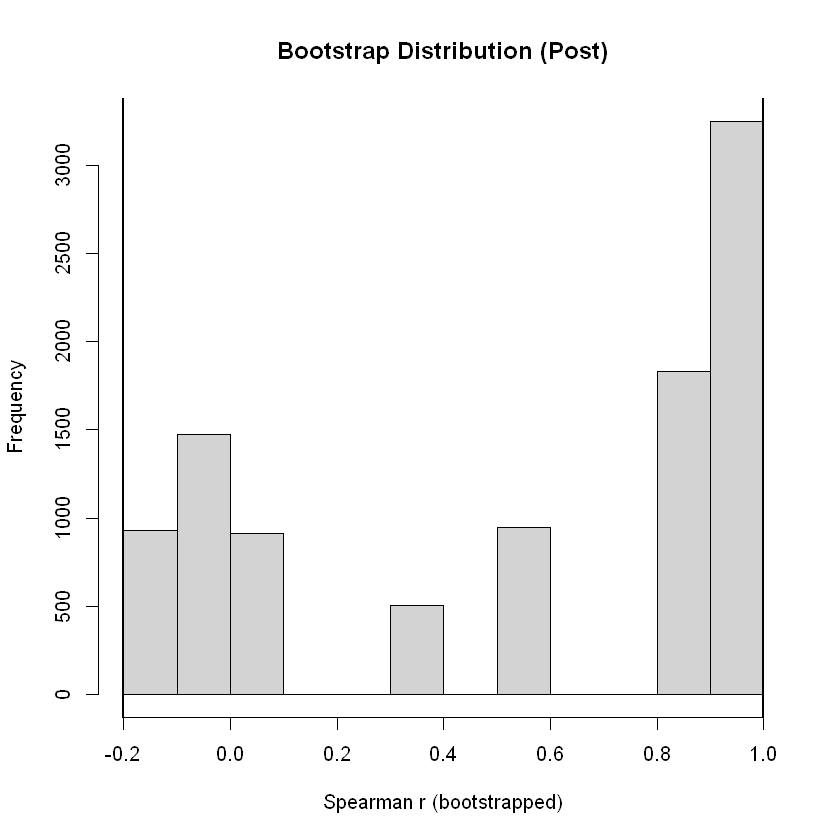

In [40]:
#Plot bootstrap histogram
hist(boot_dist, breaks = 10, main = "Bootstrap Distribution (Post)",  xlab = "Spearman r (bootstrapped)")
abline(v = spearmanCorr_post, col = "red", lwd = 2)
abline(v = ci, lwd = 2)

95% Bootstrap CI: [ 0.515 , 1 ]


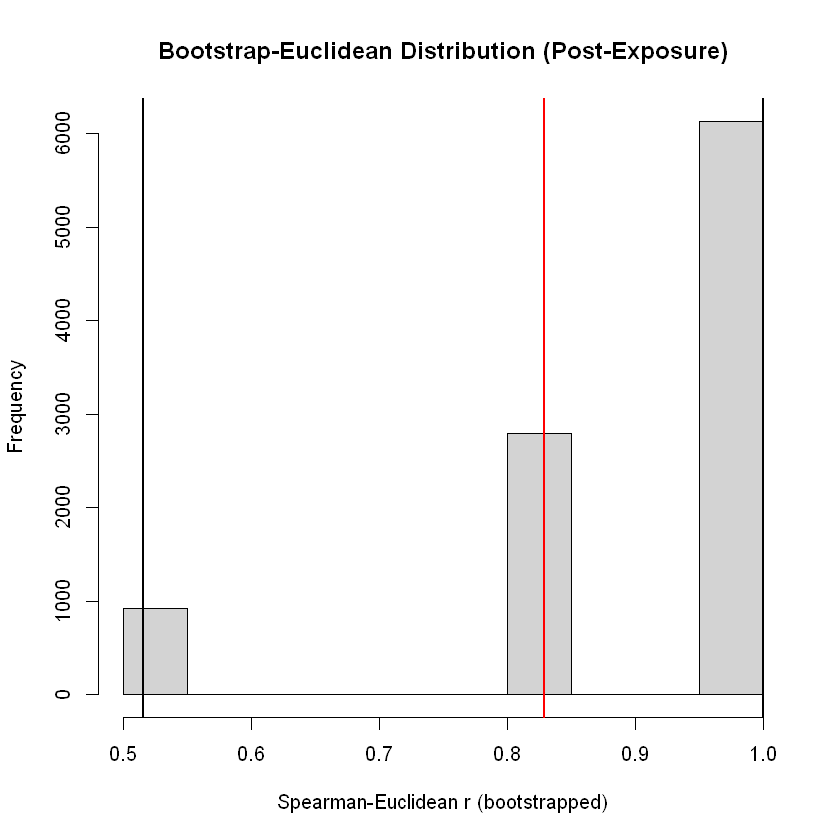

In [41]:
#Setup
set.seed(42)
n_boots   <- 10000
boot_dist <- numeric(n_boots)

for (b in 1:n_boots) {
  idx            <- sample(n, replace = TRUE)
  boot_emp       <- rdm_post[idx, idx]
  boot_model     <- group_model_rdm_euclid[idx, idx]
  ev             <- boot_emp[lower.tri(boot_emp)]
  mv             <- boot_model[lower.tri(boot_model)]
  boot_dist[b]   <- if (sd(ev) == 0 | sd(mv) == 0) NA
                    else cor(ev, mv, method = "spearman")
}

#Compute confidence intervals
ci <- quantile(boot_dist, c(0.025, 0.975), na.rm = TRUE)

cat("95% Bootstrap CI: [", round(ci[1], 3), ",", round(ci[2], 3), "]\n")

hist(boot_dist, breaks = 10, main = "Bootstrap-Euclidean Distribution (Post-Exposure)",  xlab = "Spearman-Euclidean r (bootstrapped)")
abline(v = spearmanCorr_post_euclid, col = "red", lwd = 2)
abline(v = ci, lwd = 2)

# 4. Bootstrap conclusions
>The 95% bootstrap confidence interval for the dose-based model Spearman correlation ranged from -0.20 to 1.0, indicating high uncertainty in the estimate. The quite wide interval crossing both negative to positive values suggests that the dose-based model is an unstable predictor of the empirical RDM, and that the direction of the relationship cannot be determined reliably with the current number of conditions.
>
> Now with the 95% bootstrap confidence interval for the Euclidean model Spearman correlation ranged from 0.515 to 1.0, indicating that even at the lower bound the correlation remains positive and relatively strong.
>
>However, the limited number of conditions (n = 4) where resampling produces only a few unique rank orderings may have been a critical limitationn. While the wide CI reflects uncertainty due to the small sample of conditions, the interval not crossing zero suggests the positive relationship between the Euclidean model and the empirical RDM is may be stabler and a bit more reliable. 

# Overall, RSA conclusion

> The RSA has been an interesting analysis to apply to my noise-exposure data as I typically assess windowed peak amplitudes of the FFT to look at growth level functions and temporal modulation transfer functions (TMTFs) to assess peripheral performance. Using the RSA allowed me to asses the representation geometry of the EFR profiles across noise-exposure conditions and predict if the representational dissimilarity structure of EFR amplitude patterns across modulation frequencies in a gerbil model of cochlear neural degeneration. The empirical RDM revealed that post-exposure EFR patterns were *suprisingly* most dissimilar between the 106dB and 118dB groups (dissimilarity = 0.26), while the control and 106dB groups showed the least dissimilarity (0.01), suggesting a non-monotonic relationship between noise exposure level and representational structure.
>
> A dose-based model RDM using absolute dB differences between groups showed a weak negative Spearman correlation with the empirical RDM (r = -0.20, p = 0.541), indicating that a simple linear dose-response model did not predict the observed representational geometry. I then used Euclidean distance model built from the EFR amplitude vectors themselves to see if I could better capture the strength in relationships and it did show a stronger spearman positive correlation.
>
> However, neither model reached statistical significance, which is could largely be due to the small number of conditions (n = 4) limiting the minimum permutation p-value. Yet, these findings suggest that while noise exposure does alter the representational structure of temporal coding as measured by EFR amplitudes, the effect does not follow a simple linear dose-response gradient, and the 106dB exposure level produced unexpectedly distinct EFR patterns relative to adjacent groups — a finding that warrants further investigation with increased sample sizes.
>
### Future Directions
- Remove the 106dB group from the initial dataframes as it has the *smallest* number of samples (n=6) and high variance.
     - Assess the relationships between control and 106dB individually
- Evaluate other distance metrics to better capture the non-linear relationships amongst conditions.
- Re-attempt bootstrapping by resampling animals instead or using a jackknife technique to assess goodness of fit. 

#### References


1. Kriegeskorte, N., Mur, M., & Bandettini, P. (2008). Representational similarity analysis – connecting the branches of systems neuroscience. *Frontiers in Systems Neuroscience, 2*, Article 4. https://doi.org/10.3389/neuro.06.004.2008

2. Thornton, M. A. (2018). Representational similarity analysis. *MIND Summer School Tutorial.* http://markallenthornton.com/cv/Thornton&Mitchell_CC_2017.pdf

3. Kujawa, S. G., & Liberman, M. C. (2015). Synaptopathy in the noise-exposed and aging cochlea: Primary neural degeneration in acquired sensorineural hearing loss. *Hearing Research, 330*(Pt B), 191–199. https://doi.org/10.1016/j.heares.2015.02.009



